In [1]:
from dotenv import load_dotenv
load_dotenv()

True

## Use Tavily

In [26]:
from langchain_tavily import TavilySearch

In [27]:
tavily_search_tool = TavilySearch(
    max_results=5,
    topic="general",
)

In [28]:
user_input = "What nation hosted the Euro 2024? Include only wikipedia sources."

In [ ]:
tavily_search_tool.invoke({'query': user_input})

{'query': 'What nation hosted the Euro 2024? Include only wikipedia sources.',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'title': 'UEFA Euro 2024 - Wikipedia',
   'url': 'https://en.wikipedia.org/wiki/UEFA_Euro_2024',
   'content': "It was the third time that European Championship matches were played on German territory, and the second time in reunified Germany, as West Germany hosted the 1988 tournament, and four matches of the multi-national Euro 2020 were played in Munich. Munich, the site of the first game of UEFA Euro 2024, was also a host city at the multi-national UEFA Euro 2020 tournament, hosting four matches (three involving Germany) in front of a greatly reduced number of spectators due to COVID-19 restrictions. UEFA announced the tournament schedule on 10 May 2022, which included kick-off times only for the opening match, semi-finals, and final. On 20 July 2024, after an open vote on the official Euro 2024 website, UEFA announced that Turki

In [2]:
from langgraph.graph import StateGraph, START, END, MessagesState

In [3]:
from planner_agent_state import PlannerAgentState

In [4]:
workflow = StateGraph(PlannerAgentState)

In [5]:
from langchain.chat_models import init_chat_model

In [6]:
llm = init_chat_model('gpt-4o-mini', model_provider='openai')

In [7]:
llm.invoke('What is capital of China?')

AIMessage(content='The capital of China is Beijing.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 7, 'prompt_tokens': 13, 'total_tokens': 20, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_34a54ae93c', 'id': 'chatcmpl-BjTYCrPSxZ1blMbR5cf5o3fqh7Kbi', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--9376403b-14c4-4425-a748-354591f00246-0', usage_metadata={'input_tokens': 13, 'output_tokens': 7, 'total_tokens': 20, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [8]:
from destination_prompt import prompt as find_destination_prompt

In [9]:
from user_destination import destination_parser

## Create nodes for the workflow

In [10]:
## Extract location Node
def extract_location(state: PlannerAgentState) -> PlannerAgentState:
    messages = state.get('messages', [])
    user_query = ''
    if (len(messages) > 0):
        user_query = messages[0]

    if (user_query):
        chain = find_destination_prompt | llm | destination_parser
        response = chain.invoke({'user_input': user_query})
        return {'destination_info': response}
    return state

In [11]:
## Attractions Node
def attractions(state: PlannerAgentState) -> PlannerAgentState:
    destination_info = state.get('destination_info', {})
    print('##attractions', destination_info)
    return state

In [12]:
## Restaurants Node
def restaurants(state: PlannerAgentState) -> PlannerAgentState:
    pass

In [13]:
## Transportation Node
def transportation(state: PlannerAgentState) -> PlannerAgentState:
    pass

In [14]:
## current_weather Node
def current_weather(state: PlannerAgentState) -> PlannerAgentState:
    pass

In [15]:
## Weather Forecast Node
def weather_forecast(state: PlannerAgentState) -> PlannerAgentState:
    pass

In [16]:
## Hotel Search Node
def hotel_search(state: PlannerAgentState) -> PlannerAgentState:
    pass

### Add nodes to the workflow

In [17]:
workflow.add_node('extract_location', extract_location)
workflow.add_node('attractions', attractions)
workflow.add_node('restaurants', restaurants)
workflow.add_node('transportation', transportation)
workflow.add_node('current_weather', current_weather)
workflow.add_node('weather_forecast', weather_forecast)
workflow.add_node('hotel_search', hotel_search)

### Create edges

In [18]:
workflow.add_edge(START, 'extract_location')

workflow.add_edge('extract_location', 'attractions')
workflow.add_edge('extract_location', 'restaurants')
workflow.add_edge('extract_location', 'transportation')
workflow.add_edge('extract_location', 'current_weather')
workflow.add_edge('extract_location', 'weather_forecast')
workflow.add_edge('extract_location', 'hotel_search')

In [19]:
workflow.add_edge('attractions', END)
workflow.add_edge('restaurants', END)
workflow.add_edge('transportation', END)
workflow.add_edge('current_weather', END)
workflow.add_edge('weather_forecast', END)
workflow.add_edge('hotel_search', END)

In [20]:
app = workflow.compile()

In [21]:
from IPython.display import display, Image

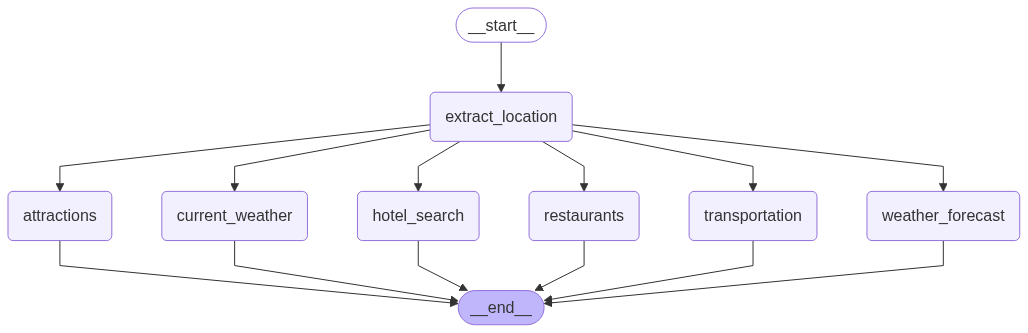

In [22]:
display(Image(app.get_graph().draw_mermaid_png()))

In [23]:
user_query = 'I want to visit Kyoto next spring. What can you tell me about getting around there?'
user_query_2 = 'Plan a cultural itinerary in Jaipur, focusing on historic landmarks.'

In [24]:
response = app.invoke({'messages': [user_query_2]})

##attractions destination='Jaipur' city='Jaipur' country='India' pincode='302001' region='Rajasthan' latitude=26.9124 longitude=75.7873


In [25]:
print(response)

{'messages': ['Plan a cultural itinerary in Jaipur, focusing on historic landmarks.'], 'destination_info': DestinationInfo(destination='Jaipur', city='Jaipur', country='India', pincode='302001', region='Rajasthan', latitude=26.9124, longitude=75.7873)}
